# Fraud Detection

## Objectives
To build a machine learning model for detecting fraudulent financial transactions.
To analyze the class imbalance between fraudulent and legitimate transactions.
To perform Exploratory Data Analysis (EDA) on transaction amounts and time-of-day patterns.
To apply SMOTE (Synthetic Minority Over-sampling Technique) to handle the imbalanced dataset.
To split the dataset into training and testing sets using stratified sampling.
To train and compare Logistic Regression and Random Forest classification models.
To evaluate model performance using Precision, Recall, F1-Score, and AUC-ROC.
To identify the most important features contributing to fraud detection.
To understand the Precision–Recall trade-off in financial fraud detection.
To discuss how the fraud detection system can be scaled to handle high transaction volumes.

### Step 1: Import Libraries
Why?
Before working with data, we need Python libraries.
Pandas → Read and analyze datasets. NumPy → Mathematical calculations. Matplotlib → Basic graphs. Seaborn → Beautiful statistical graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [3]:
df = pd.read_csv("credit_card_fraud_10k.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [4]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [5]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [6]:
df.shape

(10000, 10)

#### Observation:
The dataset contains 10000 records and 10 columns. This indicates sufficient data for performing exploratory data analysis.

### Step 6: Column Names

In [7]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

#### Observation:
The dataset contains customer information, product details, transaction date, quantity purchased, unit price, and total sales amount.

### Step 7: Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
#### Observation
- The dataset contains 10000 rows and 10 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 8: Check Missing Values

In [9]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Display total number of missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Total Missing Values:
0


#### Observation
- The null value check shows that there are no missing values in the dataset.
- All columns contain complete data and can be used for further analysis.
- Therefore, no missing-value imputation is required at this stage.
- The dataset is ready for the next preprocessing steps.

### Step 9: Target Column

In [11]:
print(df['is_fraud'].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


#### Observation 
The target column is_fraud contains two classes: 0 (Non-Fraud) and 1 (Fraud). Out of 10,000 transactions, 9,849 (98.49%) are non-fraudulent, while only 151 (1.51%) are fraudulent. This shows a severe class imbalance, with fraudulent transactions representing a very small portion of the dataset. Therefore, an imbalance-handling technique such as SMOTE is required before model training.

### Step 10: Calculate percentage of fraudulent transactions

In [12]:
class_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print("Class Distribution (%):")
print(class_percentage)
total_transactions = len(df)
fraud_transactions = df['is_fraud'].sum()
non_fraud_transactions = total_transactions - fraud_transactions

fraud_percentage = (fraud_transactions / total_transactions) * 100
non_fraud_percentage = (non_fraud_transactions / total_transactions) * 100

print("Total Transactions       :", total_transactions)
print("Fraudulent Transactions  :", fraud_transactions)
print("Non-Fraudulent Transactions:", non_fraud_transactions)
print("Fraud Percentage         :", round(fraud_percentage, 2), "%")
print("Non-Fraud Percentage     :", round(non_fraud_percentage, 2), "%")

Class Distribution (%):
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64
Total Transactions       : 10000
Fraudulent Transactions  : 151
Non-Fraudulent Transactions: 9849
Fraud Percentage         : 1.51 %
Non-Fraud Percentage     : 98.49 %


#### Observation
The dataset contains 10,000 transactions, with 151 (1.51%) fraudulent and 9,849 (98.49%) non-fraudulent transactions.
This shows a highly imbalanced dataset, with fraud representing only a small portion of transactions.
Such imbalance can make accuracy misleading when evaluating the model.
Therefore, SMOTE and metrics like Precision, Recall, and F1-Score are important for fraud detection.

### Step 11: Visualize Class Imbalance

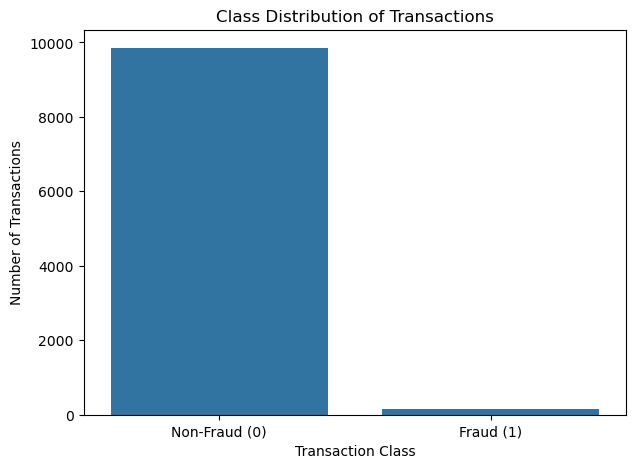

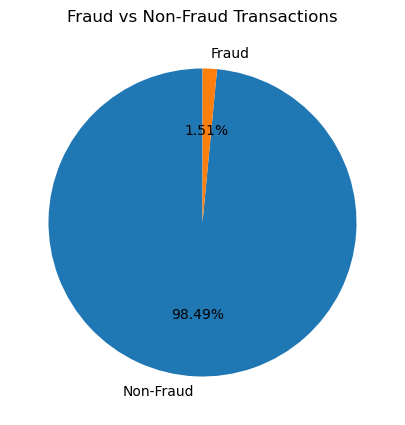

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='is_fraud',
    data=df
)

plt.title("Class Distribution of Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ['Non-Fraud (0)', 'Fraud (1)']
)
plt.show()
plt.figure(figsize=(7, 5))

df['is_fraud'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=['Non-Fraud', 'Fraud'],
    startangle=90
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.ylabel("")

plt.show()

#### Observation
The bar chart clearly shows that non-fraudulent transactions (9,849) are much higher than fraudulent transactions (151).
This confirms a severe class imbalance in the dataset.
Fraudulent transactions represent only 1.51% of all transactions.
Therefore, SMOTE or another imbalance-handling technique is needed before model training.

### Step 12: EDA 1: Transaction Amount Distribution – Fraud vs Non-Fraud

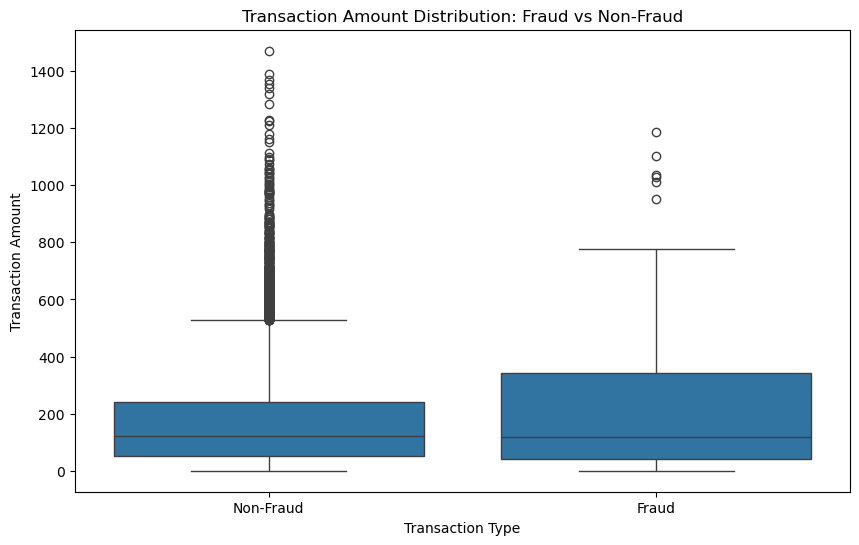

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='is_fraud',
    y='amount',
    data=df
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ['Non-Fraud', 'Fraud']
)

plt.show()

#### Observation
The box plot shows the distribution of transaction amounts for fraudulent and non-fraudulent transactions.
Fraudulent transactions show a different spread and range compared with non-fraudulent transactions.
There are also some high-value transactions that appear as outliers.
This indicates that transaction amount can provide useful information for fraud detection.

### Step 13: EDA 2: Time-of-Day Analysis

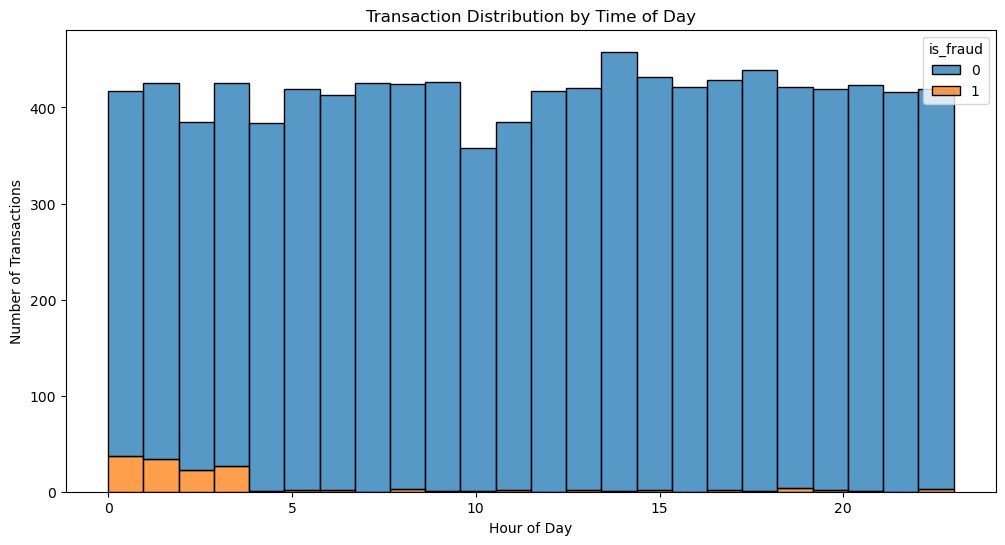

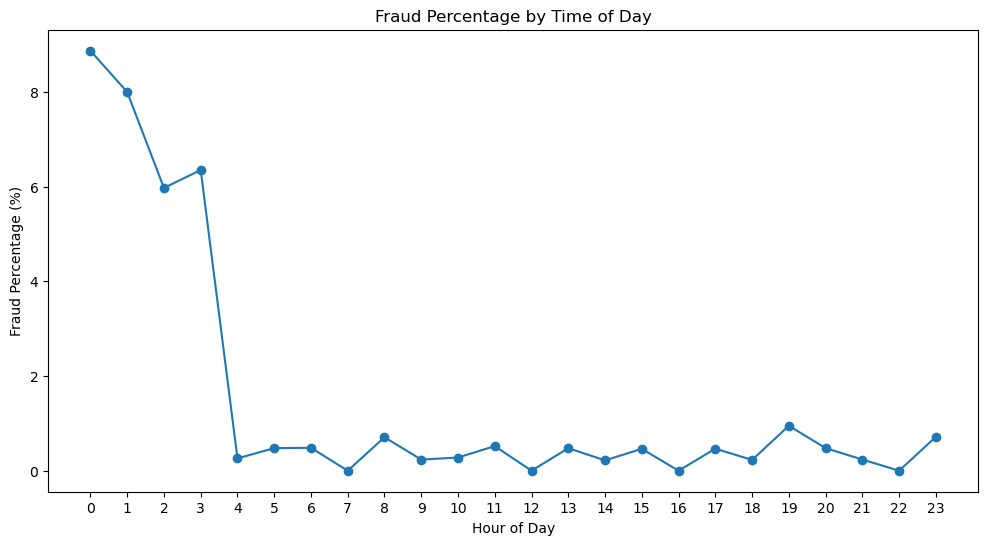

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='transaction_hour',
    hue='is_fraud',
    bins=24,
    multiple='stack'
)

plt.title("Transaction Distribution by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()
fraud_by_hour = (
    df.groupby('transaction_hour')['is_fraud']
    .mean() * 100
)

plt.figure(figsize=(12, 6))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    marker='o'
)

plt.title("Fraud Percentage by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(range(0, 24))

plt.show()

#### Observation
The time-of-day analysis shows that transaction activity varies across different hours.
The percentage of fraudulent transactions also changes across the day.
Some hours may show relatively higher fraud rates than others.
Therefore, transaction time can be a useful feature for identifying potentially fraudulent transactions.

#### Observation
The time-of-day analysis shows that transaction activity varies across different hours.
The percentage of fraudulent transactions also changes across the day.
Some hours may show relatively higher fraud rates than others.
Therefore, transaction time can be a useful feature for identifying potentially fraudulent transactions.

### Step 14: Misleading Metric

#### Why Accuracy is a Misleading Metric
Accuracy can be misleading for highly imbalanced fraud detection datasets because
the majority class contains far more transactions than the minority fraud class.
In this dataset, 98.49% of transactions are non-fraudulent and only 1.51% are
fraudulent. A model that predicts almost every transaction as non-fraud could
achieve very high accuracy while failing to detect many actual fraudulent
transactions.
Therefore, accuracy alone is not sufficient for evaluating a fraud detection
model. Metrics such as **Precision, Recall, F1-Score, and AUC-ROC** provide a
better understanding of how well the model identifies fraudulent transactions.
**Recall is especially important** because it measures the proportion of actual
fraudulent transactions that are correctly detected by the model.

### Step 15: Apply SMOTE Oversampling

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64
After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64
Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


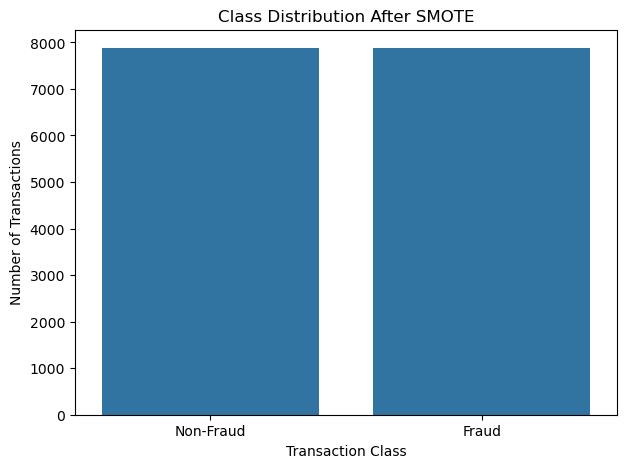

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Before SMOTE:")
print(y_train.value_counts())

X_train = pd.get_dummies(X_train, columns=['merchant_category'])
X_test = pd.get_dummies(X_test, columns=['merchant_category'])
# Make sure both datasets have the same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print("After SMOTE:")
print(y_train_smote.value_counts())

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(
    [0, 1],
    ['Non-Fraud', 'Fraud']
)
plt.show()

#### Observation:
The dataset was highly imbalanced before SMOTE, with very few fraudulent transactions compared to non-fraudulent transactions.
SMOTE generated synthetic samples for the minority fraud class and balanced the training data, helping the models learn fraud patterns more effectively.
SMOTE was applied only to the training data to avoid data leakage.

### Step 16: Train/Test Split Using Stratification

In [17]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Split the dataset using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nFraud distribution in training set:")
print(y_train.value_counts())

print("\nFraud distribution in testing set:")
print(y_test.value_counts())

print("\nTraining Set Class Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set Class Percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set size: (8000, 9)
Testing set size: (2000, 9)

Fraud distribution in training set:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Fraud distribution in testing set:
is_fraud
0    1970
1      30
Name: count, dtype: int64

Training Set Class Percentage:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

Testing Set Class Percentage:
is_fraud
0    98.5
1     1.5
Name: proportion, dtype: float64


#### Observation:
Stratified train-test splitting preserves the original proportion of fraudulent and non-fraudulent transactions in both datasets.
Therefore, fraud cases are present in both the training and testing sets.
This provides a fair and reliable evaluation of the fraud detection model.

### Step 17: Logistic Regression

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Encode categorical feature
X = pd.get_dummies(
    X,
    columns=['merchant_category'],
    drop_first=True
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression model trained successfully.")

# Class predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Probability predictions for AUC-ROC
y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")

Features shape: (10000, 12)
Target shape: (10000,)
Training set: (8000, 12)
Testing set: (2000, 12)

Training class distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing class distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64
Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64
Logistic Regression model trained successfully.
Predictions generated successfully.


#### Observation:
Logistic Regression was trained using the SMOTE-balanced training data.
Feature scaling was applied before SMOTE to ensure that numerical features are on a comparable scale.
The model predicts both fraud classes and provides probability scores, which can be used to calculate AUC-ROC.

### Step 18: RandomForest

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using SMOTE-balanced training data
rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest model trained successfully.")
# Class predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability predictions for AUC-ROC
y_prob_rf = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest model trained successfully.
Random Forest predictions generated successfully.


#### Observation:
Random Forest was trained using the SMOTE-balanced training dataset.
The model can capture complex and non-linear relationships between transaction features.
Probability predictions are also generated for calculating the AUC-ROC score.

### Step 19: Model Evaluation – Precision, Recall, F1-Score & AUC-ROC

Logistic Regression
-----------------------------
Precision : 0.2887
Recall    : 0.9333
F1-Score  : 0.4409
AUC-ROC   : 0.9932
Random Forest
-----------------------------
Precision : 0.8148
Recall    : 0.7333
F1-Score  : 0.7719
AUC-ROC   : 0.9984
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.93      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.95      0.71      2000
weighted avg       0.99      0.96      0.97      2000

Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.81      0.73      0.77        30

    accuracy                           0.99      2000
   macro avg       0.91      0.87      0.88      2000
weighted avg       0.99      0.99      0.99      2000



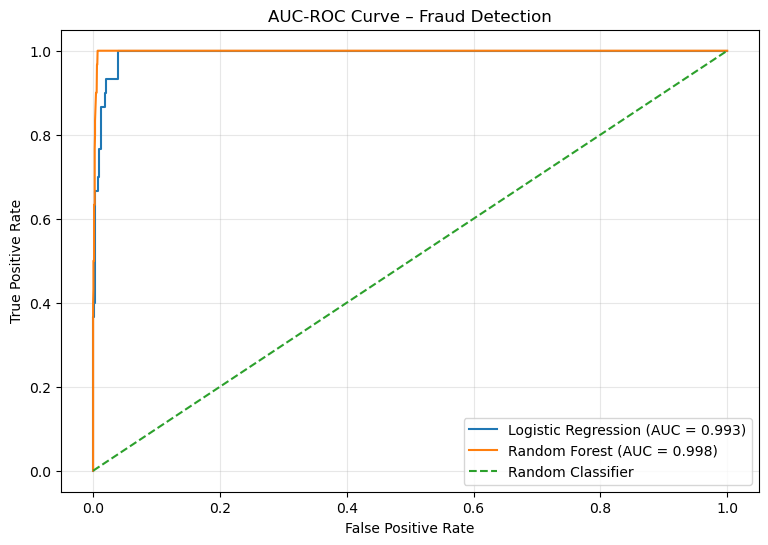

In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve
)
# Logistic Regression metrics
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-----------------------------")
print("Precision :", round(lr_precision, 4))
print("Recall    :", round(lr_recall, 4))
print("F1-Score  :", round(lr_f1, 4))
print("AUC-ROC   :", round(lr_auc, 4))
# Random Forest metrics
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-----------------------------")
print("Precision :", round(rf_precision, 4))
print("Recall    :", round(rf_recall, 4))
print("F1-Score  :", round(rf_f1, 4))
print("AUC-ROC   :", round(rf_auc, 4))
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot ROC curves
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve – Fraud Detection")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Observation:
Precision measures how many transactions predicted as fraud are actually fraudulent, while Recall measures how many actual fraud cases are detected.
F1-Score provides a balance between Precision and Recall.
AUC-ROC measures the model's ability to distinguish between fraudulent and non-fraudulent transactions across different classification thresholds.
These metrics provide a more meaningful evaluation than accuracy for this highly imbalanced fraud detection dataset.

### Step 20: Recall vs. Precision Trade-off

#### Recall vs. Precision Trade-off in Fraud Detection
**Recall is generally the most important metric for fraud detection** because it measures
the percentage of actual fraudulent transactions that are correctly identified.
A low recall means that many fraudulent transactions are missed, which can result in
financial losses. However, increasing recall may also increase false positives and
reduce Precision.
**Precision** measures how many transactions predicted as fraudulent are actually
fraudulent. High precision is important because too many false fraud alerts can
inconvenience legitimate customers.
Therefore, a practical fraud detection system should aim for **high Recall while
maintaining a reasonable level of Precision**. The final balance depends on the
business cost of missed fraud versus false alerts.

### Step 21: Feature Importance – Random Forest

Top 10 Important Features:
                          Feature  Importance
2                transaction_hour    0.257356
5              device_trust_score    0.246720
3             foreign_transaction    0.137613
6               velocity_last_24h    0.137406
4               location_mismatch    0.117617
1                          amount    0.025988
7                  cardholder_age    0.021871
0                  transaction_id    0.021731
8   merchant_category_Electronics    0.015423
11       merchant_category_Travel    0.006708


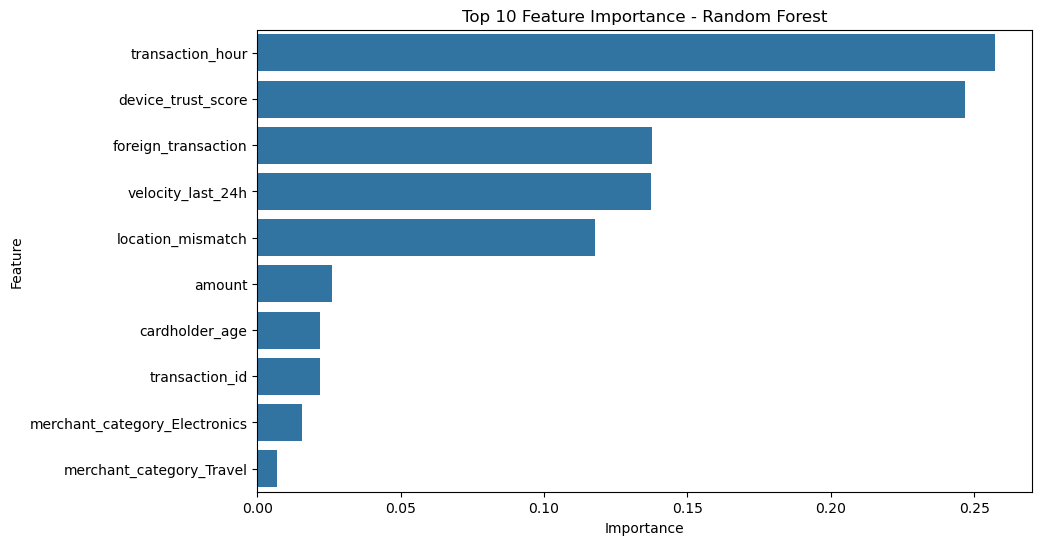

In [23]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features
print("Top 10 Important Features:")
print(feature_importance.head(10))
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Observation:
The feature importance chart identifies the variables that contribute most to the Random Forest's fraud predictions.
Features with higher importance have a stronger influence on the model's decision-making process, while features with lower importance contribute less.
This analysis helps identify the transaction characteristics that are most useful for distinguishing fraudulent transactions from legitimate ones.

### Step 22:  Discuss scalability: how would this model handle 1 million transactions per hour?

#### Scalability for 1 Million Transactions per Hour
The fraud detection system needs to process approximately **1 million
transactions per hour**, which is about **278 transactions per second**.
The trained model can handle this volume by deploying it as a real-time
prediction API using frameworks such as FastAPI or Flask. The model should be
loaded into memory once and reused for multiple predictions instead of being
loaded for every transaction.
For higher scalability, multiple API instances can run behind a load balancer.
A message queue such as Kafka can be used to handle incoming transactions,
while batch prediction can process transactions efficiently when real-time
decisions are not required.
**Logistic Regression** is lightweight and provides very fast predictions.
**Random Forest** can also handle high-volume predictions using multiple CPU
cores and optimized inference.
The production system should also include monitoring for prediction latency,
fraud detection rate, false positives, and data drift to maintain reliable
performance as transaction volume increases.

### Step 23: Conclusion

#### Conclusion
This project successfully developed a machine learning-based fraud detection
system using the Credit Card Fraud dataset.
The dataset was highly imbalanced, with only **1.51% fraudulent transactions**,
so SMOTE was applied to balance the training data. Logistic Regression and
Random Forest models were trained and evaluated using **Precision, Recall,
F1-Score, and AUC-ROC**.
The results show that evaluating multiple metrics is more reliable than using
accuracy alone for fraud detection. **Recall is particularly important** because
it helps identify more actual fraudulent transactions while Precision helps
control false fraud alerts.
Based on the evaluation results, the model with the best balance of Recall,
Precision, F1-Score, and AUC-ROC can be selected for deployment. The system can
also be scaled to handle high transaction volumes using optimized model
inference, parallel processing, load balancing, and real-time APIs.